In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import itertools

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [3]:
from true_graph import TrueGraph
from learner import FactorGraphLearner, learner_to_graph
from noise_generator import IndependentMarginals
from metrics import *
from random_graph import generate_random_graph, generate_random_tree
from chow_liu import chow_liu

# One Example

(<Figure size 800x600 with 1 Axes>, <Axes: title={'center': 'Factor Graph'}>)

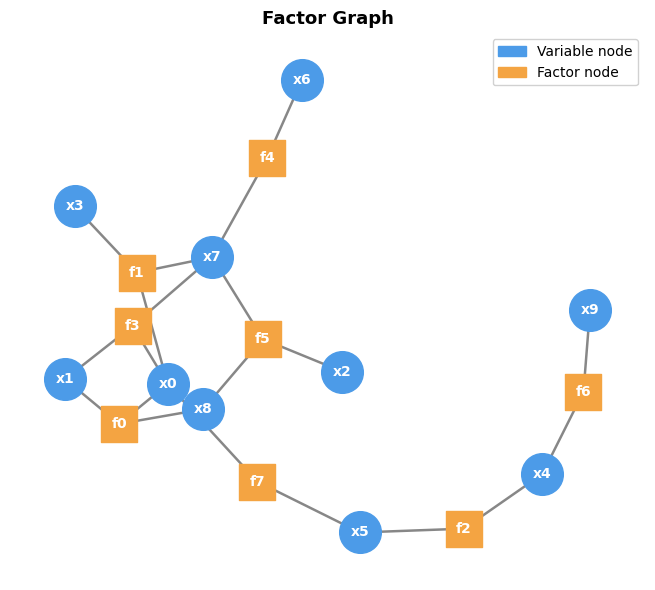

In [20]:
rng = np.random.default_rng(614)
graph = generate_random_graph(n=10, alphabet_size=2, rng=rng, n_factors=8)
graph.display_graph(seed=106)

In [83]:
samples = graph.sample(500)

100%|████████████████████████████████████████| 500/500 [00:01<00:00, 353.37it/s]


In [84]:
ng = IndependentMarginals(samples, alphabet_size=2, alpha=1, seed=295)
learner = FactorGraphLearner(
    n_vars=10,
    alphabet_size=2,
    K=10,
    noise_generator=ng,
    hidden_dims=(16,16),
    max_factor_size=5,
    shared_mlp=False,
    seed=811
)

losses, diagnostics = learner.train(
    samples,
    n_epochs=100,
    lr=0.01,
    lambda_mask=0,
    lambda_weight=0,
    lambda_mlp_l2=1e-2,
    lambda_bp=1e-3,
    penalty_schedule=True,
    verbose=True,
    log_every=10
)

Epoch   10/100  loss=0.6926  main=0.6924  reg=0.0003
Epoch   20/100  loss=0.6335  main=0.6017  reg=0.0318
Epoch   30/100  loss=0.6551  main=0.5915  reg=0.0636
Epoch   40/100  loss=0.6317  main=0.5861  reg=0.0456
Epoch   50/100  loss=0.6283  main=0.6057  reg=0.0226
Epoch   60/100  loss=0.6461  main=0.6370  reg=0.0090
Epoch   70/100  loss=0.6405  main=0.6350  reg=0.0055
Epoch   80/100  loss=0.5951  main=0.5886  reg=0.0064
Epoch   90/100  loss=0.6044  main=0.5968  reg=0.0076
Epoch  100/100  loss=0.5973  main=0.5936  reg=0.0037


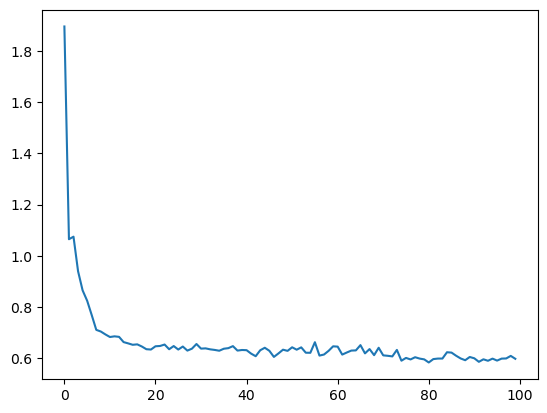

In [85]:
plt.plot(losses['Total'])

In [86]:
structural_hamming_distance(graph, learner)

11

(<Figure size 800x600 with 1 Axes>, <Axes: title={'center': 'Factor Graph'}>)

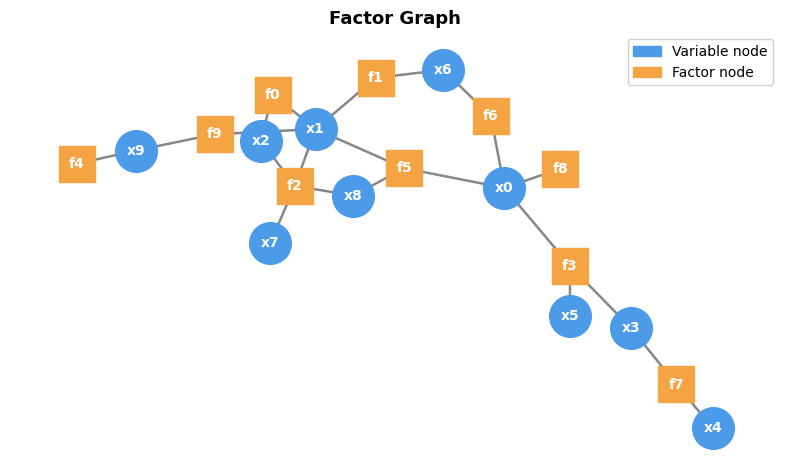

In [87]:
learner_to_graph(learner).display_graph(seed=50)

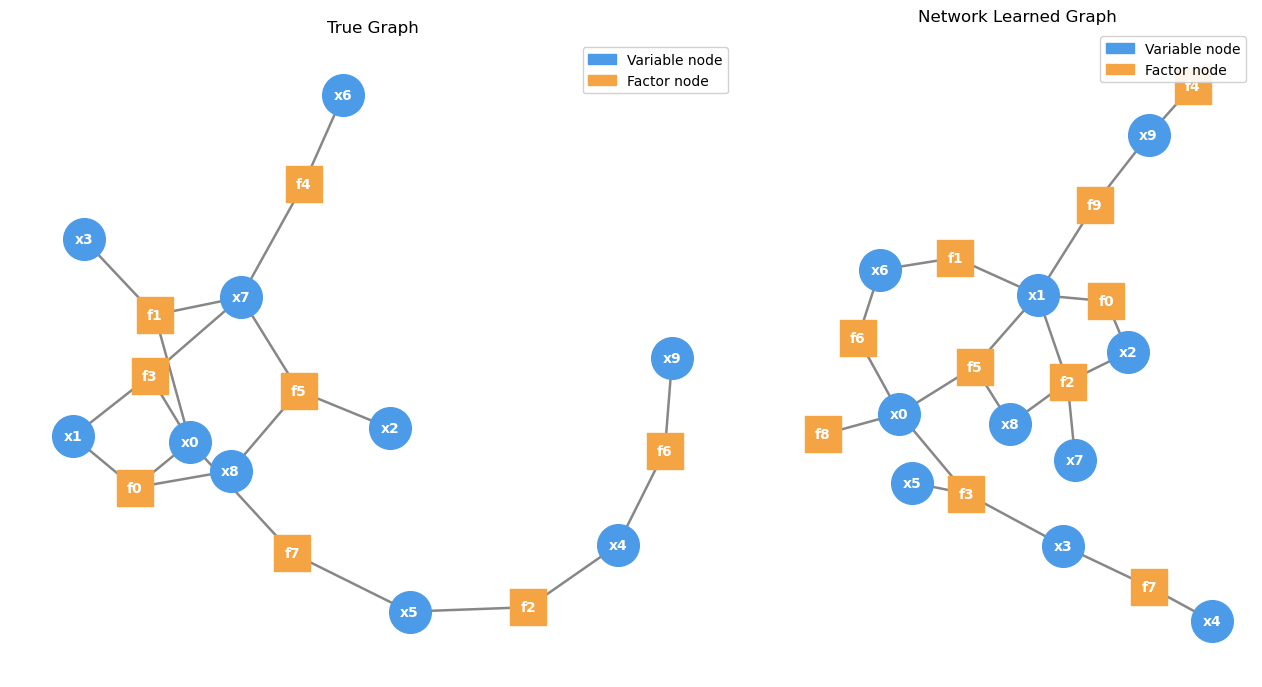

In [93]:
fig, axs = plt.subplots(1,2, figsize=(14,7))

graph.display_graph(seed=106, ax=axs[0])
learner_to_graph(learner).display_graph(seed=53, ax=axs[1])

axs[0].set_title("True Graph")
axs[1].set_title("Network Learned Graph")

# plt.savefig("../img/proof.png")
plt.show()